# **Lista de Atividades**
**Autor:** Pedro Melo
**Disciplina:** Aprendizado Profundo
**Professor:** Tiago Maritan

### Importando bibliotecas

In [86]:
import pandas as pd
import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, kurtosistest
from statsmodels.stats.stattools import jarque_bera

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import (
    HistGradientBoostingRegressor, 
    HistGradientBoostingClassifier,
    RandomForestClassifier
)
from keras.callbacks import EarlyStopping
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from scipy.stats.mstats import winsorize
from pprint import pprint
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import random
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
keras.utils.set_random_seed(42)

## Questão 2

O naufrágio do Titanic é um dos eventos mais emblemáticos do século XX. Embora a sobrevivência de um passageiro tivesse um elemento de acaso, estudos mostram que fatores como sexo, idade e classe socioeconômica influenciaram significativamente as chances de escapar. Implemente uma Rede Perceptron de Múltiplas Camadas que faça a predição se um passageiro sobreviveu ou não ao acidente do Titanic. Neste exercício, você deve tentar criar um modelo preditivo, usando os dados de passageiros (ou seja, nome, idade, sexo, classe socioeconômica, etc.), que procure responder à pergunta: "que tipo de pessoa tem mais probabilidade de sobreviver?" A base de dados do problema pode ser acessada através do seguinte link: https://www.kaggle.com/c/titanic/data.

Apresente também a curva do erro médio de treinamento com relação ao número de épocas e a curva do erro médio com o conjunto de validação ou teste. Calcule e apresente também a matriz de confusão do modelo. Algumas recomendações:

- Explore a base de dados, identificando valores ausentes, inconsistências e outliers.
- Realize o preenchimento de dados faltantes usando técnicas adequadas
- Remova ou transforme atributos irrelevantes ou redundantes;
- Avalie e, se necessário, aplique normalização ou padronização das variáveis numéricas;
- Analise a correlação entre atributos e o rótulo, justificando suas escolhas.
Caso exista desbalanceamento entre as classes, aplique técnicas de balanceamento.

### Leitura e exploração inicial

In [87]:
train = pd.read_csv("titanic/titanic_train.csv")
test = (
    pd.read_csv("titanic/titanic_test.csv")
    .merge(pd.read_csv("titanic/titanic_gender_submission.csv"), 
    on='PassengerId', how="inner")
)[list(train.columns)]

df = pd.concat([train, test], ignore_index=True)

In [88]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
dtypes: float64(2), int64(5), str(5)
memory usage: 122.8 KB


In [90]:
num_cols = df.select_dtypes(include="number").columns
df[num_cols].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.377387,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.484918,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


**Observações iniciais**:

- survived como target do modelo
- passengerid apenas como o id unico da base

**Possiveis variaveis importantes ao modelo:**
- Pclass;
- Sex;
- Age;
- SibSp (esposas ou irmaos);
- Parch (pais ou filhos);
- fare;
- embarked (port of embarkation)

**Variáveis Problemáticas**
- Age com alguns faltantes, mas não o suficiente para excluir da base. Simple Inputer ou estimação com modelo pode ser útil;
- Cabin com uma quantia muito grande de nulos, podendo ser eliminada;
- Embarked com apenas dois nulos, podendo então ter apenas estas linhas removidas.
- Age também possui um mínimo estranho, com 0.17;
- Fare aparenta ser uma variável muito assimétrica, o que pode ser corrigido com transformações nesta variável.

A tipagem das variáveis parece ser consistente

### Limpeza Inicial

Remoção de variáveis sem potencial de explicação ou que possuem muitos nulos.
Preenchimento de nulos e remoção de outliers será realizada após análise exploratória unidimensional, confirmando suspeitas.

In [91]:
useless = ["PassengerId", "Ticket"]
target = "survived"
df["title"] = df["Name"].str.split(", ").str[1].str.split(".").str[0]
titulos_raros = [title for title in df["title"] if df["title"].value_counts().loc[title] <= 15]

df = (
    df
    .drop(useless, axis=1)
    .set_axis(["survived", "p_class", "name", "sex", 
               "age", "sib_sp", "parch", "fare",
               "cabin", "port", "title"], axis="columns")
    .assign(
        # agregando variáveis em uma so
        fam_members = lambda x: x["sib_sp"] + x["parch"] + 1,
        fam_size = lambda x: np.select(
            [
                x["fam_members"] == 1,
                x["fam_members"] <= 4
            ],
            ["alone", "small"], default="large"),

        # extraindo alcunha
        title_temp = lambda x: (
            x["title"].replace(titulos_raros, "Rare")
        ),

        title = lambda x: x["title_temp"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    )
    .drop(["sib_sp", "parch", "title_temp", 
           "fam_members", "name", "cabin"], axis=1)
)

### EDA

Esta parte pode ser dividida entre análise uni e bidimensional

Na análise unidimensional, avaliamos as distribuições, histogramas e boxplots das variáveis de forma isolada, bem como algumas estatísticas acerca delas. Já na bidimensional, analisamos de fato a relação entre cada variável e a sua alvo, bem como problemas de multicolinearidade, podendo definir quais variáveis estarão inclusas no modelo.

**Análise Unidimensional**

In [92]:
# configs

cat_cols = df.select_dtypes(include="object").columns

colors = sns.color_palette("husl")
sns.set_style("darkgrid")

/var/folders/48/3p26d_ds0vl0fbwqp5n9rtnc0000gn/T/ipykernel_54588/1936896389.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


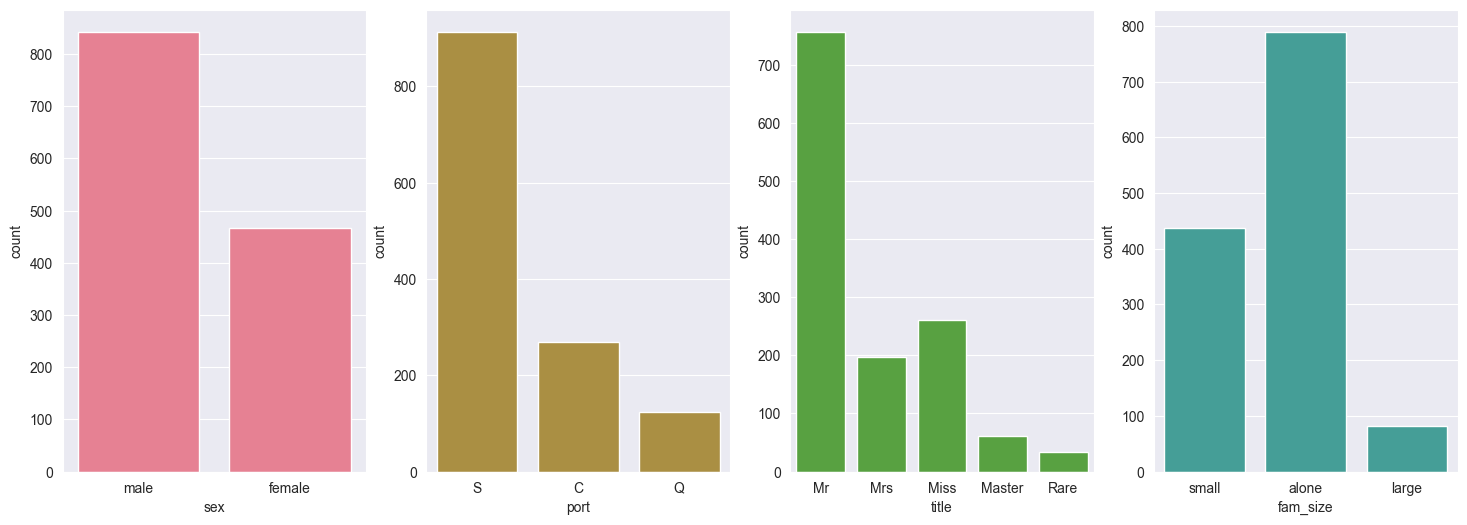

In [93]:
axs_cat = plt.subplots(1, len(cat_cols), figsize=(18, 6))[1]

for i, (col, ax) in enumerate(zip(cat_cols, axs_cat)):

    sns.countplot(df, x=col, ax=ax, color=colors[i])

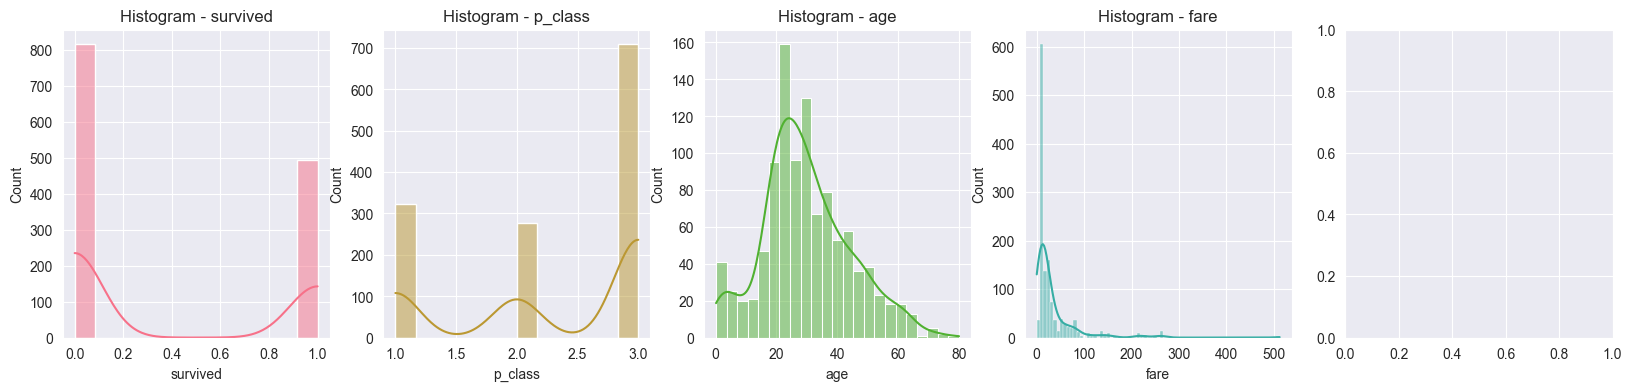

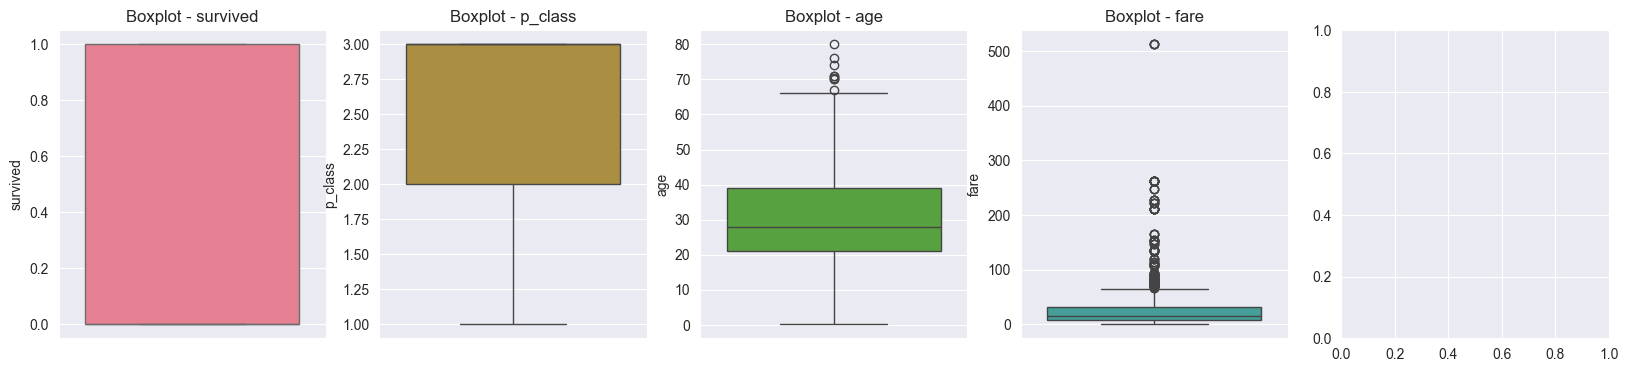

In [94]:
num_cols = df.select_dtypes(include="number").columns
axs_num_hist = plt.subplots(1, 5, figsize=(20, 4))[1]
axs_num_box = plt.subplots(1, 5, figsize=(20, 4))[1]

for i, (col, ax) in enumerate(zip(num_cols, axs_num_hist.flatten())):

    sns.histplot(df, x=col, ax=axs_num_hist[i], color=colors[i], kde=True)
    sns.boxplot(df, y=col, ax=axs_num_box[i], color=colors[i], orient="v")

    axs_num_hist[i].set_title(f"Histogram - {col}")
    axs_num_box[i].set_title(f"Boxplot - {col}")

In [95]:
def var_momentums(column: str):

    var = df[column].fillna(df[column].mean())

    return {
        "Jarque Bera (> 0.05)": jarque_bera(var)[1],
        "Shapiro (> 0.05)": shapiro(var)[1],
        "Curtose (> 0.05)": kurtosistest(var)[1],
        "Coef. Variação": var.std() / var.mean()
    }

In [96]:
for var in num_cols:
    
    print(f"Momentos e estatíticas de {var}")

    pprint(var_momentums(var))
    print("-" * 50 + "\n")

Momentos e estatíticas de survived
{'Coef. Variação': np.float64(1.2849353617897532),
 'Curtose (> 0.05)': np.float64(0.0),
 'Jarque Bera (> 0.05)': np.float64(7.078462230139211e-49),
 'Shapiro (> 0.05)': np.float64(4.1723803888790216e-47)}
--------------------------------------------------

Momentos e estatíticas de p_class
{'Coef. Variação': np.float64(0.36508899761381386),
 'Curtose (> 0.05)': np.float64(0.0),
 'Jarque Bera (> 0.05)': np.float64(3.9080080679910453e-38),
 'Shapiro (> 0.05)': np.float64(4.835997221713328e-42)}
--------------------------------------------------

Momentos e estatíticas de age
{'Coef. Variação': np.float64(0.4311480167570328),
 'Curtose (> 0.05)': np.float64(7.780528418253024e-07),
 'Jarque Bera (> 0.05)': np.float64(8.477571199409486e-21),
 'Shapiro (> 0.05)': np.float64(4.710372412823463e-19)}
--------------------------------------------------

Momentos e estatíticas de fare
{'Coef. Variação': np.float64(1.5539310485750857),
 'Curtose (> 0.05)': np.flo

**Comentários**:

- As variáveis categóricas mostram-se de certa forma desbalanceadas e, além disso, a variável p_class deve estar na classe das categóricas, tendo em vista que representa a classe da passagem do viajante;
- A variável alvo não parece ter um grande desbalanceamento, mas alguma técnica pode ser aplicada;
- As variáveis `fare` e `fam_members` tem uma grande assimetria à direita, o que pode implicar no uso de técnicas de winsorização e normalização das variáveis;
- Pelos testes de Shapiro, Curtose e Jarque-Bera, nenhuma das séries apresenta distribuição normal.

**Análise bidimensional**

Analisando a relação e movimentação conjunta entre as variáveis numéricas/categórias e a alvo.

Para categóricas, podemos usar o teste de chi2, sobretudo.
Para as numéricas, podemos usar os boxplots segregados e também a descrição das estatísticas das variáveis para dierentes grupos.
Podemos avaliar como as variáveis se comportam dependendo da alvo, basicamente.

In [97]:
# cast para categóricas

df["sex"] = df["sex"].map({"male": 1, "female": 0})
df["port"] = df["port"].map({"S": 1, "C": 2, "Q": 3})
df["fam_size"] = df["fam_size"].map({"alone": 1, "small": 2, "large": 3})
df["title"] = df["title"].map({"Mr": 1, "Mrs": 2, "Miss": 3, "Master": 4, "Rare": 5})

temp_num_cols = df.select_dtypes(include="number").columns
num_cols = [col for col in temp_num_cols if df[col].nunique() > 5 and col != target]
temp_cat_cols = df.select_dtypes(include="str").columns
cat_cols = list(temp_cat_cols) + [col for col in temp_num_cols if df[col].nunique() <= 5 and col != target]

print(f"Colunas numéricas ajustadas: {num_cols}")
print(f"Colunas categóricas ajustadas: {cat_cols}")

Colunas numéricas ajustadas: ['age', 'fare']
Colunas categóricas ajustadas: ['p_class', 'sex', 'port', 'title', 'fam_size']


In [98]:
def chi2_test(col):

    """O p-valor deve ser < 0.05"""
    temp_df = df.copy()

    temp_df[col] = temp_df[col].fillna(temp_df[col].mean())

    cross_tab = pd.crosstab(df[col], df[target])

    stat, p_value, dof, expected = chi2_contingency(cross_tab)

    return {col: [stat, p_value, dof, expected]}

In [99]:
cat_cols

['p_class', 'sex', 'port', 'title', 'fam_size']

In [100]:
dic = {}
for col in cat_cols:
    dic[col] = chi2_test(col)[col]

chi2_df = pd.DataFrame(dic).T.rename(columns={0:"stat", 1: "p_value (< 0.05)", 2: "dof", 3: "expected"})
chi2_df

,stat,p_value (< 0.05),dof,expected
p_class,91.723676,0.0,2,"[[201.1038961038961, 121.8961038961039], [172...."
sex,617.313352,0.0,1,"[[290.1375095492742, 175.86249045072574], [524..."
port,24.684434,0.000004,2,"[[569.9387911247131, 344.0612088752869], [168...."
title,624.518504,0.0,4,"[[471.31779984721163, 285.68220015278837], [12..."
fam_size,95.436875,0.0,2,"[[491.86401833460656, 298.13598166539344], [27..."


Estatísticas da coluna age agregada por survived


,count,mean,std,min,25%,50%,75%,max
survived,,,,,,,,
0,629.0,30.510986,13.912218,0.33,21.0,28.0,39.0,74.0
1,417.0,28.931079,15.105581,0.17,19.0,28.0,38.0,80.0


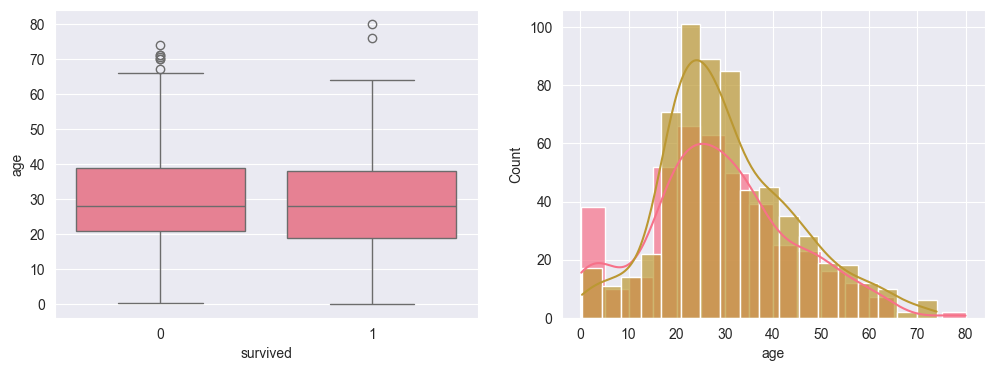

Estatísticas da coluna fare agregada por survived


,count,mean,std,min,25%,50%,75%,max
survived,,,,,,,,
0,814.0,23.879124,34.906946,0.0,7.854200,10.5,26.0000,263.0000
1,494.0,48.811497,68.594401,0.0,11.431275,26.0,56.9823,512.3292


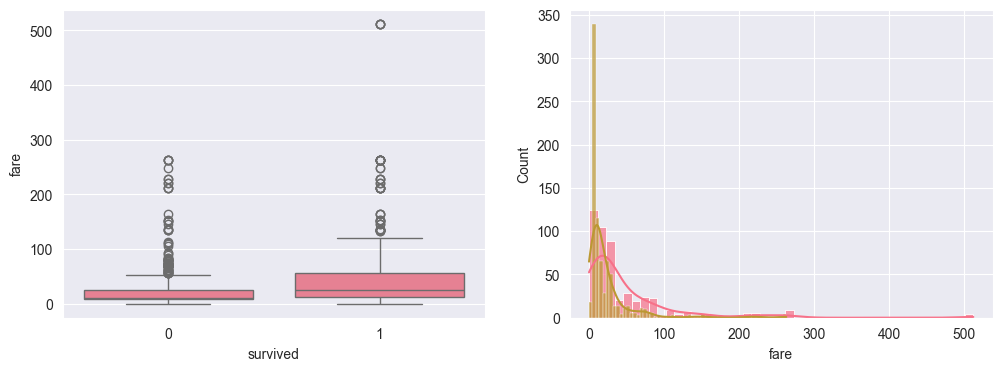

In [101]:
for col in num_cols:

    print(f"Estatísticas da coluna {col} agregada por {target}")
    
    df_agg = df.groupby(target)[col].describe()
    df_surv1 = df[df["survived"] == 1]
    df_surv0 = df[df["survived"] == 0]
    ax = plt.subplots(1, 2, figsize=(12,4))[1]

    sns.boxplot(df, x=target, y=col, orient="v", ax=ax[0], color=colors[0])
    sns.histplot(df_surv1, x=col, kde=True, ax=ax[1], color=colors[0], alpha=0.7)
    sns.histplot(df_surv0, x=col, kde=True, ax=ax[1], color=colors[1], alpha=0.7)

    display(df_agg)
    plt.show()

**Comentários:**

Com relação às variáveis qualitativas, ambas as 3 passaram no teste de chi_2, o que nos permite afirmar que tem existe uma relação entre cada uma delas e a variável alvo.

Já para as variáveis quantitativas, apenas a `age` não apresenta diferenças significativas nas estatísticas se agregamos pela média. Com isso, podemos excluí-la do nosso modelo e deixar como variáveis finais:

`fare`, `fam_members`, `sex`, `port`, `p_class`

**Análise de Multicolinearidade**

In [102]:
df[num_cols].corr()

,age,fare
age,1.00000,0.17874
fare,0.17874,1.00000


In [103]:
df_vif_prep = df.copy().dropna()

vif = [VIF(df_vif_prep[num_cols].values, i) for i in range(len(num_cols))]

df_VIF = pd.DataFrame({
    "var": num_cols,
    "VIF": vif
})

df_VIF

,var,VIF
0,age,1.454233
1,fare,1.454233


Valores muito baixos tanto na matriz var-corr quanto na análise de inflação de variância. Isso nos permite usar todas as variáveis sem problemas de multicolinearidade.

**Dataframe Final**

In [104]:
def df_cleaner(df, cols_to_input: list[str], cols_to_win: list[str], 
                 regressor: bool=True):

    age_bins = [0, 12, 18, 35, 60, 120]
    age_labels = ["child", "teen", "young", "adult", "old"]

    df_copy = (
        df.copy()[["survived", "sex", "age", "fam_size", "fare", "port", "p_class", "title"]]
        .dropna(subset=["fare", "port"])
        .assign(
            # evitando que categoricas sejam tratadas como ordinais
            port = df["port"].map({1: "S", 2: "C", 3: "Q"}),
            age_temp = lambda x: x.groupby(["sex", "title"])["age"].transform(
               lambda y: y.fillna(y.median())
               ),
            age = lambda x: pd.cut(x["age_temp"], age_bins, include_lowest=True, labels=age_labels),
            title = df["title"].map({1: "Mr", 2: "Mrs", 3: "Miss", 4: "Master", 5: "Rare"})
            ).drop("age_temp", axis=1)
    )

    df_copy = pd.get_dummies(df_copy, drop_first=True)

    # sem necessidade de padronizacao por ser modelo rapido de arvore apenas para inputing

    # for col in cols_to_input:
        
    #     train_df = df_copy[~df_copy[col].isna()]
    #     x = train_df.drop(col, axis=1)
    #     y = train_df[col]

    #     x_to_pred = df_copy[df_copy[col].isna()].drop(col, axis=1)

    #     if regressor == True:
    #         model = HistGradientBoostingRegressor()

    #     else:
    #         model = HistGradientBoostingClassifier()
        
    #     model.fit(x, y)

    #     y_pred = model.predict(x_to_pred)

    #     df_copy.loc[x_to_pred.index, col] = [round(value, 2) for value in y_pred]

    for col in cols_to_win:

        mean = df_copy[col].mean()
        std = df_copy[col].std()

        print(f"Estatísticas antes da winsorização: {col}")
        print("-" * 50)
        print(f"Média: {mean}")
        print(f"Dev-Pad: {std}")

        df_copy[col] = winsorize(df_copy[col], limits=[0, 0.05])

        mean = df_copy[col].mean()
        std = df_copy[col].std()

        print(f"\nEstatísticas depois da winsorização")
        print("-" * 50)
        print(f"Média: {mean}")
        print(f"Dev-Pad: {std}")
        print("-" * 50 + "\n")

    return df_copy

In [105]:
clean_df = (
    df_cleaner(df, ["age"], ["fare"], regressor=True)
)

clean_df

Estatísticas antes da winsorização: fare
--------------------------------------------------
Média: 33.22395627871363
Dev-Pad: 51.76598590355328

Estatísticas depois da winsorização
--------------------------------------------------
Média: 29.086012710566617
Dev-Pad: 33.02448266748676
--------------------------------------------------



,survived,sex,fam_size,fare,p_class,age_teen,age_young,age_adult,age_old,port_Q,port_S,title_Miss,title_Mr,title_Mrs,title_Rare
0,0,1,2,7.2500,3,False,True,False,False,False,True,False,True,False,False
1,1,0,2,71.2833,1,False,False,True,False,False,False,False,False,True,False
2,1,0,1,7.9250,3,False,True,False,False,False,True,True,False,False,False
3,1,0,2,53.1000,1,False,True,False,False,False,True,False,False,True,False
4,0,1,1,8.0500,3,False,True,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,0,1,1,8.0500,3,False,True,False,False,False,True,False,True,False,False
1305,1,0,1,108.9000,1,False,False,True,False,False,False,False,False,False,True
1306,0,1,1,7.2500,3,False,False,True,False,False,True,False,True,False,False
1307,0,1,1,8.0500,3,False,True,False,False,False,True,False,True,False,False


In [106]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 1306 entries, 0 to 1308
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    1306 non-null   int64  
 1   sex         1306 non-null   int64  
 2   fam_size    1306 non-null   int64  
 3   fare        1306 non-null   float64
 4   p_class     1306 non-null   int64  
 5   age_teen    1306 non-null   bool   
 6   age_young   1306 non-null   bool   
 7   age_adult   1306 non-null   bool   
 8   age_old     1306 non-null   bool   
 9   port_Q      1306 non-null   bool   
 10  port_S      1306 non-null   bool   
 11  title_Miss  1306 non-null   bool   
 12  title_Mr    1306 non-null   bool   
 13  title_Mrs   1306 non-null   bool   
 14  title_Rare  1306 non-null   bool   
dtypes: bool(10), float64(1), int64(4)
memory usage: 74.0 KB


**Transformação de variáveis**

Colunas a serem transformadas:
- `fam_members` e `fare` podem ter transformação log(x+1)



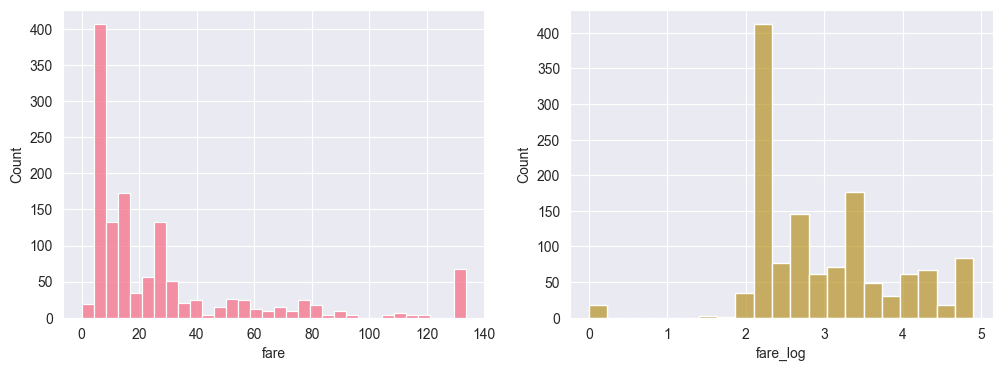

In [107]:
cols_to_log = ["fare"]

for col in cols_to_log:

    axs = plt.subplots(1, 2, figsize=(12, 4))[1]

    sns.histplot(clean_df, x=col, ax=axs[0], color=colors[0])
    clean_df[f"{col}_log"] = np.log(1 + clean_df[col])
    sns.histplot(clean_df, x=f"{col}_log", ax=axs[1], color=colors[1])

Sem muita melhora na distribuição da fem_members, usaremos  variável normal. Para fare, iremos utilizar a normalizada.

**Pré-processamento**

Colunas a serem normalizadas ou padronizadas (Min Max Scaler):
- `fam_members`
- `fare`

Variáveis categóricas já devidamente tratadas.

Usar `train_test_split`

In [108]:
int_cols = ["port_Q", "port_S", "title_Miss", 
            "title_Mr", "title_Mrs", "title_Rare", 
            "age_teen", "age_young", "age_adult",
            "age_old"]

for col in int_cols:
    clean_df[col] = clean_df[col].astype(int)

X = clean_df.drop([target, "fare"], axis=1)
y = clean_df[target]
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)
print(X_train_full.shape)

(1044, 14)


In [109]:
clean_df

,survived,sex,fam_size,fare,p_class,age_teen,age_young,age_adult,age_old,port_Q,port_S,title_Miss,title_Mr,title_Mrs,title_Rare,fare_log
0,0,1,2,7.2500,3,0,1,0,0,0,1,0,1,0,0,2.110213
1,1,0,2,71.2833,1,0,0,1,0,0,0,0,0,1,0,4.280593
2,1,0,1,7.9250,3,0,1,0,0,0,1,1,0,0,0,2.188856
3,1,0,2,53.1000,1,0,1,0,0,0,1,0,0,1,0,3.990834
4,0,1,1,8.0500,3,0,1,0,0,0,1,0,1,0,0,2.202765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,0,1,1,8.0500,3,0,1,0,0,0,1,0,1,0,0,2.202765
1305,1,0,1,108.9000,1,0,0,1,0,0,0,0,0,0,1,4.699571
1306,0,1,1,7.2500,3,0,0,1,0,0,1,0,1,0,0,2.110213
1307,0,1,1,8.0500,3,0,1,0,0,0,1,0,1,0,0,2.202765


In [110]:
X_train, X_valid = X_train_full[:700], X_train_full[700:]
y_train, y_valid = y_train_full[:700], y_train_full[700:]

In [111]:
preprocessor = ColumnTransformer(
    transformers=[
        ("min_max", MinMaxScaler(), ["fare_log"])
    ],
    remainder="passthrough"
)

X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)
X_test = preprocessor.transform(X_test)

**Construíndo RNAs**

In [112]:
def build_nn(n_hidden, input_shape, 
                initial_neurons=32, hidden_actv_func="relu",
                output_func="sigmoid"):

    try:
        model = keras.models.Sequential(
            [
                keras.layers.Dense(
                    initial_neurons,
                    activation=hidden_actv_func,
                    input_shape=(input_shape,),
                )
            ]
        )

        half = n_hidden//2
        last_layer = initial_neurons
        for i in range(1, half+1):

            model.add(
                keras.layers.Dense((last_layer * 2),
                                   activation=hidden_actv_func)
            )

            last_layer = (last_layer * 2)

        for i in range(1, (n_hidden - half + 1)):

            model.add(
                keras.layers.Dense(int((last_layer / 2)), 
                                   activation=hidden_actv_func)
            )

            last_layer = (last_layer / 2)

        model.add(keras.layers.Dense(1, activation=output_func))

    except Exception as error:
        raise Exception(f"Não foi possível construir o modelo dentro das especificações: {error}") from error

    return model

Testando rede
----------------------------------------
N-hidden: 2
Initial Neurons: 16
Batch Size: 16
Epochs: 10


/Users/pedroafmelo/Documents/ufpb/deep_learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


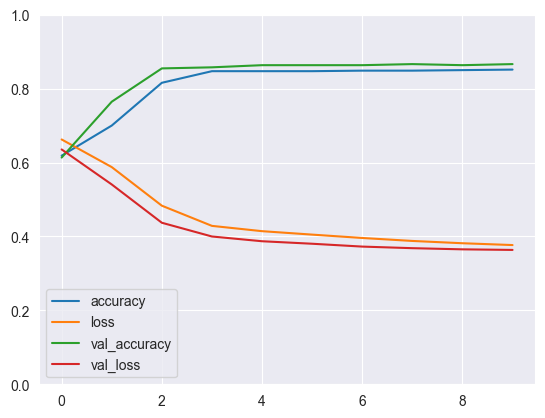

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       163
           1       0.82      0.76      0.79        99

    accuracy                           0.85       262
   macro avg       0.84      0.83      0.83       262
weighted avg       0.85      0.85      0.85       262

----------------------------------------
Testando rede
----------------------------------------
N-hidden: 2
Initial Neurons: 16
Batch Size: 16
Epochs: 30


/Users/pedroafmelo/Documents/ufpb/deep_learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


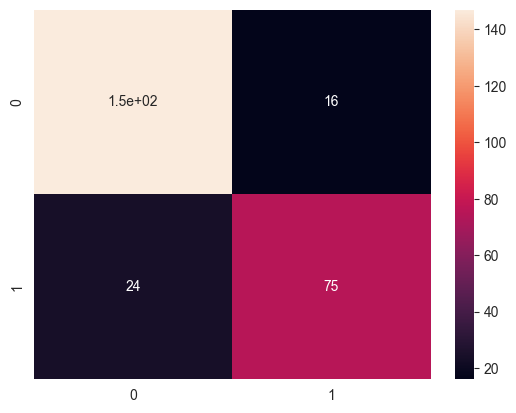

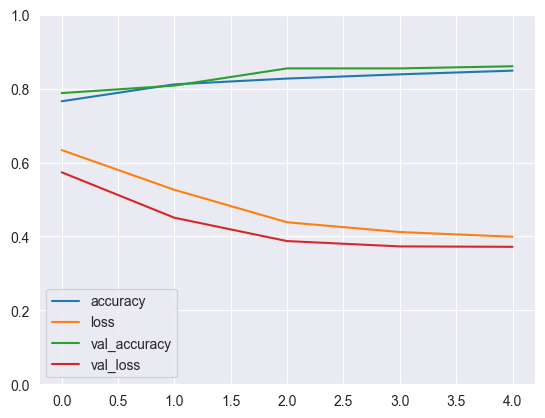

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       163
           1       0.79      0.65      0.71        99

    accuracy                           0.80       262
   macro avg       0.80      0.77      0.78       262
weighted avg       0.80      0.80      0.80       262

----------------------------------------
Testando rede
----------------------------------------
N-hidden: 2
Initial Neurons: 16
Batch Size: 32
Epochs: 10


/Users/pedroafmelo/Documents/ufpb/deep_learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


/Users/pedroafmelo/Documents/ufpb/deep_learning/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pedroafmelo/Documents/ufpb/deep_learning/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pedroafmelo/Documents/ufpb/deep_learning/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

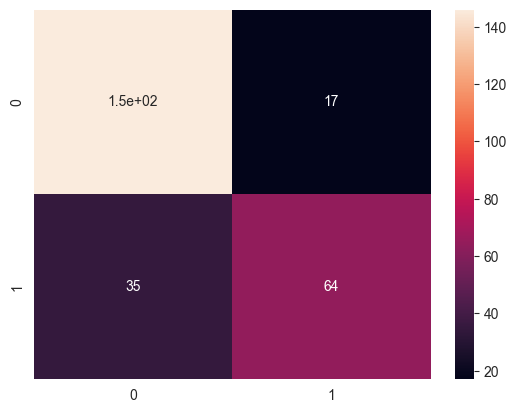

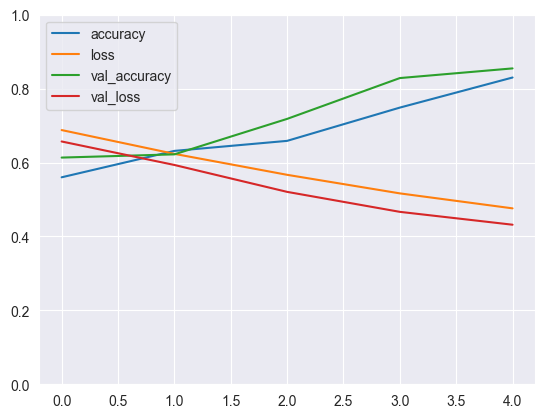

              precision    recall  f1-score   support

           0       0.62      1.00      0.77       163
           1       0.00      0.00      0.00        99

    accuracy                           0.62       262
   macro avg       0.31      0.50      0.38       262
weighted avg       0.39      0.62      0.48       262

----------------------------------------
Testando rede
----------------------------------------
N-hidden: 2
Initial Neurons: 16
Batch Size: 32
Epochs: 30


/Users/pedroafmelo/Documents/ufpb/deep_learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


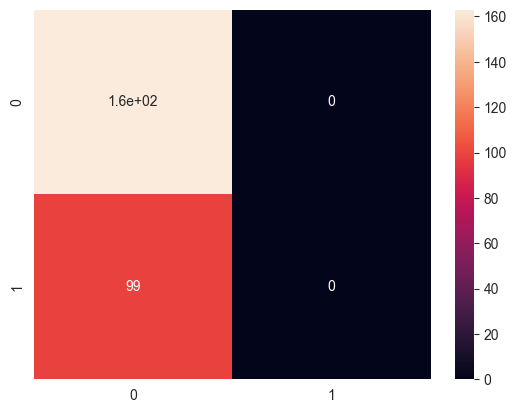

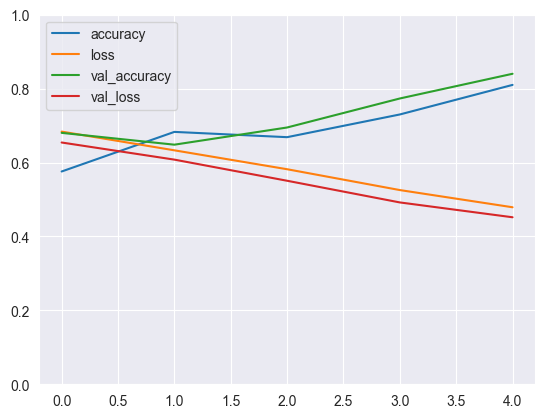

              precision    recall  f1-score   support

           0       0.67      0.96      0.79       163
           1       0.75      0.21      0.33        99

    accuracy                           0.68       262
   macro avg       0.71      0.58      0.56       262
weighted avg       0.70      0.68      0.61       262

----------------------------------------
Testando rede
----------------------------------------
N-hidden: 2
Initial Neurons: 32
Batch Size: 16
Epochs: 10


/Users/pedroafmelo/Documents/ufpb/deep_learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


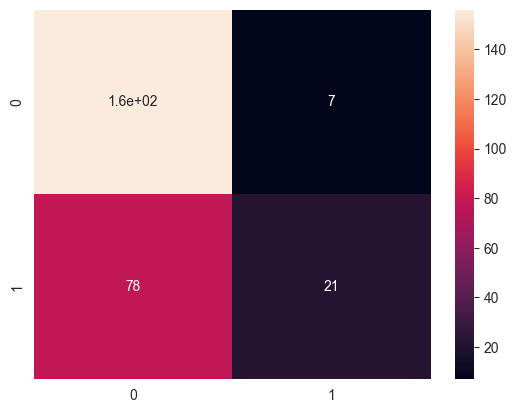

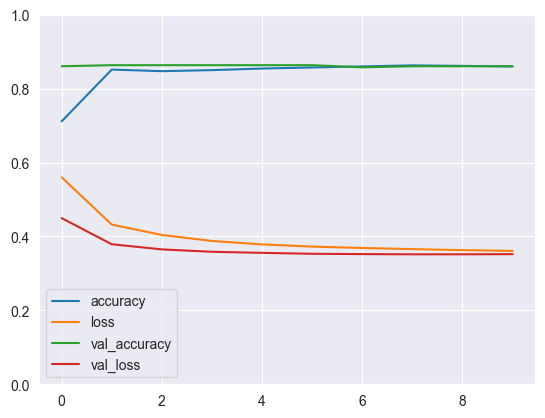

              precision    recall  f1-score   support

           0       0.86      0.92      0.89       163
           1       0.85      0.75      0.80        99

    accuracy                           0.85       262
   macro avg       0.85      0.83      0.84       262
weighted avg       0.85      0.85      0.85       262

----------------------------------------
Testando rede
----------------------------------------
N-hidden: 2
Initial Neurons: 32
Batch Size: 16
Epochs: 30


/Users/pedroafmelo/Documents/ufpb/deep_learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


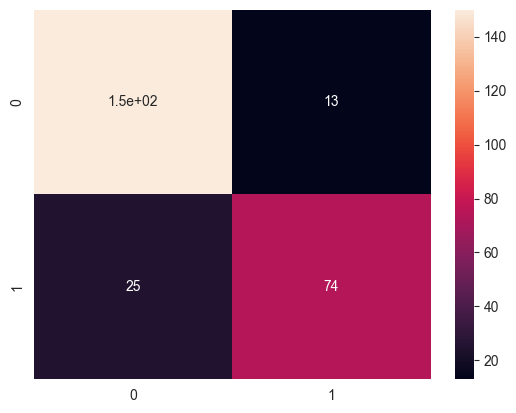

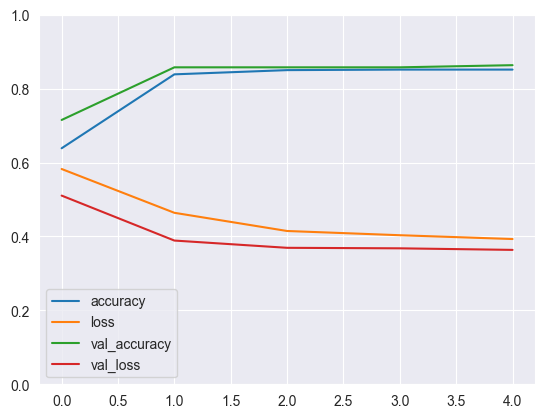

              precision    recall  f1-score   support

           0       0.70      0.99      0.82       163
           1       0.97      0.30      0.46        99

    accuracy                           0.73       262
   macro avg       0.83      0.65      0.64       262
weighted avg       0.80      0.73      0.69       262

----------------------------------------
Testando rede
----------------------------------------
N-hidden: 2
Initial Neurons: 32
Batch Size: 32
Epochs: 10


/Users/pedroafmelo/Documents/ufpb/deep_learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


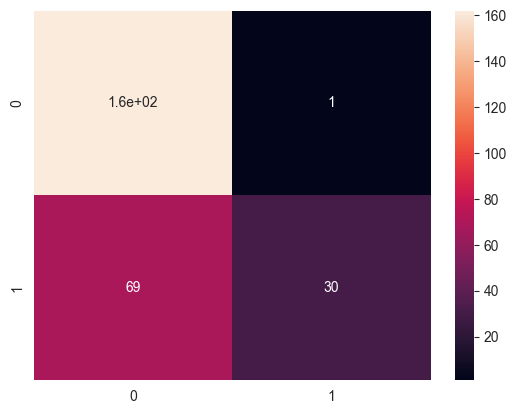

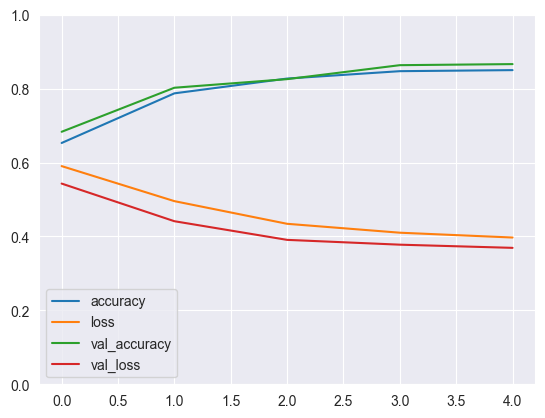

              precision    recall  f1-score   support

           0       0.68      0.99      0.81       163
           1       0.96      0.24      0.39        99

    accuracy                           0.71       262
   macro avg       0.82      0.62      0.60       262
weighted avg       0.79      0.71      0.65       262

----------------------------------------
Testando rede
----------------------------------------
N-hidden: 2
Initial Neurons: 32
Batch Size: 32
Epochs: 30


/Users/pedroafmelo/Documents/ufpb/deep_learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


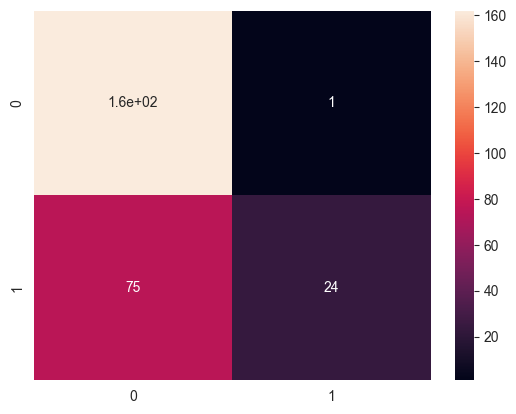

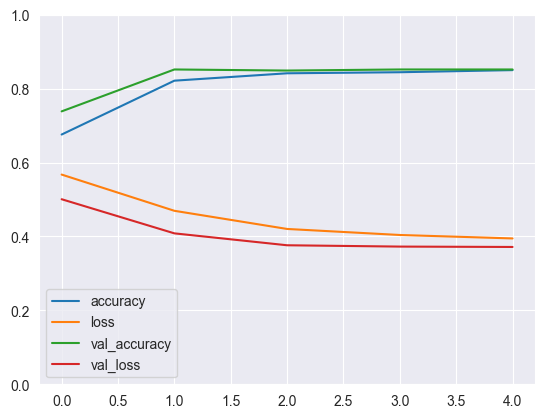

              precision    recall  f1-score   support

           0       0.71      0.94      0.81       163
           1       0.80      0.36      0.50        99

    accuracy                           0.73       262
   macro avg       0.75      0.65      0.66       262
weighted avg       0.74      0.73      0.69       262

----------------------------------------


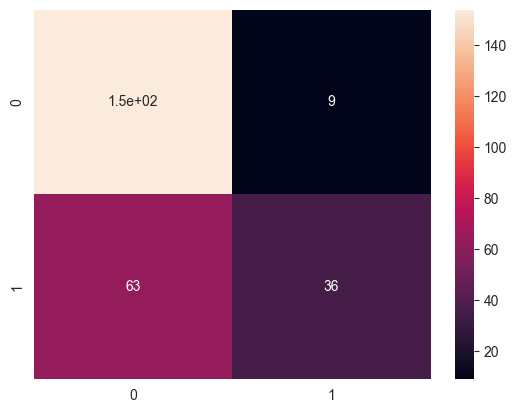

In [113]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
nns = {
    "NN_2": {"n_hidden": 2, "initial_neurons": 8},
    "NN_4": {"n_hidden": 4, "initial_neurons": 16},
    "NN_8": {"n_hidden": 8},
    "NN_12": {"n_hidden": 12, "initial_neurons": 48},
}

results = []
optimizer = "adam"
loss = "binary_crossentropy"
metrics = ["accuracy"]
validation_data = (X_valid, y_valid)
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

epoch_size = X_train.shape[0]

params = {
    "batch_size": [16, 32],
    "epochs": [10, 30],
    "n_hidden": [2],
    "initial_neurons": [16, 32]
}

for n_hidden in params["n_hidden"]:

    for initial_neurons in params["initial_neurons"]:

        for batch in params["batch_size"]:
        
            for epochs in params["epochs"]:

                print(f"Testando rede")
                print("-"*40)
                print(f"N-hidden: {n_hidden}")
                print(f"Initial Neurons: {initial_neurons}")
                print(f"Batch Size: {batch}")
                print(f"Epochs: {epochs}")

                nn = build_nn(n_hidden=n_hidden, initial_neurons=initial_neurons,
                              input_shape=X_train.shape[1]) # reconstruindo a rede a cada iteração para teste justo
                
                nn.compile(optimizer=optimizer, loss=loss, metrics=metrics)    

                history = nn.fit(X_train, y_train, batch_size=batch, epochs=epochs,
                                validation_data=validation_data, verbose=False,
                                callbacks=[early_stop])
                
                pd.DataFrame(history.history).plot()
                plt.grid(True)
                plt.gca().set_ylim(0, 1)

                accuracy = nn.evaluate(X_test, y_test, verbose=False)[1]
                y_pred = np.where(nn.predict(X_test) > .5, 1, 0)

                conf_matrix = confusion_matrix(y_test, y_pred)
                class_report = classification_report(y_test, y_pred)

                plt.show()
                plot = sns.heatmap(conf_matrix, annot=True)
                print(class_report)
                
                results.append(
                    {
                        "n_hidden": n_hidden,
                        "initial_neurons": initial_neurons,
                        "batch_size": batch,
                        "epochs": epochs,
                        "accuracy": accuracy
                    }
                )

                print("-"*40)

In [114]:
nn_results_df = pd.DataFrame(results)

# modelos comparativos com machine learning tradicional

models = {
    "logit": LogisticRegression(random_state=42),
    "rf_classifier": RandomForestClassifier(random_state=42),
    "SVC": SVC(random_state=42)
}

results_ml = []

X_ml = preprocessor.fit_transform(X)
y_ml = y

for name, model in models.items():

    scores = cross_val_score(model, X_ml, y_ml, cv=20, scoring="accuracy")
    
    results_ml.append(
        {
            "n_hidden": f"- ({name})",
            "initial_neurons": "-",
            "batch_size": "-",
            "epochs": "-",
            "accuracy": scores.mean()
        }
    )

ml_results_df = pd.DataFrame(results_ml)

results_total_df = pd.concat([nn_results_df, 
                              ml_results_df], 
                              ignore_index=True).sort_values("accuracy", ascending=False)

results_total_df.to_excel("resultados_titanic.xlsx", index=False)
display(results_total_df)

,n_hidden,initial_neurons,batch_size,epochs,accuracy
10,- (SVC),-,-,-,0.865373
8,- (logit),-,-,-,0.858520
4,2,32,16,10,0.854962
0,2,16,16,10,0.847328
9,- (rf_classifier),-,-,-,0.837809
1,2,16,16,30,0.801527
5,2,32,16,30,0.732824
7,2,32,32,30,0.725191
6,2,32,32,10,0.709924
3,2,16,32,30,0.675573


Maiores acurácias:
- NN com 2 camadas ocultas, 16 neurônios na primeira oculta, batch-size 16 e 30 épocas de treinamento;
- Logit;
- Random Forrest Classifier.

Epoch 1/10


/Users/pedroafmelo/Documents/ufpb/deep_learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7514 - loss: 0.5267 - val_accuracy: 0.8634 - val_loss: 0.4056
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8471 - loss: 0.4244 - val_accuracy: 0.8634 - val_loss: 0.3753
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 978us/step - accuracy: 0.8500 - loss: 0.4076 - val_accuracy: 0.8634 - val_loss: 0.3680
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - accuracy: 0.8529 - loss: 0.3958 - val_accuracy: 0.8663 - val_loss: 0.3617
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step - accuracy: 0.8586 - loss: 0.3833 - val_accuracy: 0.8634 - val_loss: 0.3560
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       163
           1       0.82      0.77      0.79        99

    accuracy                           0.85       262
   macro avg       0.84      0.83      0.84       262
weighted avg       0.85      0.85      0.85       262



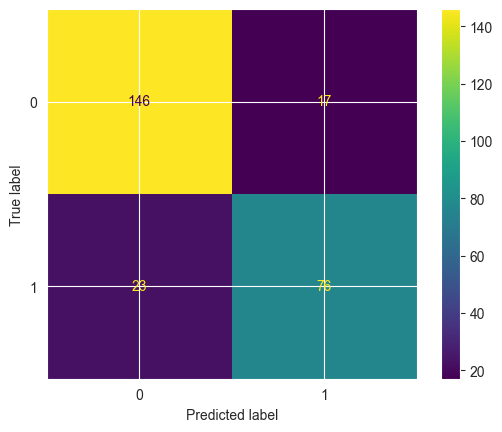

In [118]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
best_model = build_nn(2, X_train.shape[1], 32)
best_model.compile("adam", "binary_crossentropy", metrics=["accuracy"])
history = best_model.fit(X_train, y_train, 16, 10, callbacks=[early_stop], validation_data=(X_valid, y_valid))

# logit = LogisticRegression(random_state=42, class_weight="balanced")
# logit.fit(X_train, y_train)
probas= (best_model.predict(X_test) > 0.5).astype(int)
conf_matrix = confusion_matrix(y_test, probas)
report = classification_report(y_test, probas)
disp = ConfusionMatrixDisplay(conf_matrix)
disp.plot()
print(report)

In [119]:
best_model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8473 - loss: 0.4353 


[0.4353298842906952, 0.847328245639801]